# QQQ (Invesco QQQ Trust)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ruptures import Binseg
from pandas.plotting import autocorrelation_plot

%matplotlib inline

C:\Users\niush\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
file_path = "QQQ_categorized_data.csv"

categorized_df = pd.read_csv(file_path, delimiter=',')

In [3]:
categorized_df.head()

,Date,Open,High,Low,Close,Volume,Open_category,High_category,Low_category,Close_category,Volume_category
0,1999-03-11,45.994,46.260,44.988,45.880,21670048,"(44.998, 47.088]","(45.505, 47.593]","(44.8, 46.887]","(45.124, 47.216]","(19838994.529, 22246375.057]"
1,1999-03-12,45.721,45.749,44.406,44.770,19553768,"(44.998, 47.088]","(45.505, 47.593]","(42.713, 44.8]","(43.033, 45.124]","(17263097.362000003, 19838994.529]"
2,1999-03-23,44.991,45.160,43.567,43.650,24517597,"(42.908, 44.998]","(43.417, 45.505]","(42.713, 44.8]","(43.033, 45.124]","(22246375.057, 24653755.586]"
3,1999-03-24,44.045,45.164,43.374,45.136,18890150,"(42.908, 44.998]","(43.417, 45.505]","(42.713, 44.8]","(45.124, 47.216]","(17263097.362000003, 19838994.529]"
4,1999-03-25,45.829,46.776,45.529,46.776,18192179,"(44.998, 47.088]","(45.505, 47.593]","(44.8, 46.887]","(45.124, 47.216]","(17263097.362000003, 19838994.529]"


# Time series analysis

formatting date

In [4]:
# Check the Date column
print(categorized_df['Date'].head(10))

# Convert the Date column to datetime with a specified format
categorized_df['Date'] = pd.to_datetime(categorized_df['Date'], format='%Y-%m-%d', errors='coerce')

# Identify invalid dates
invalid_dates = categorized_df[categorized_df['Date'].isna()]
print("Invalid Dates:")
print(invalid_dates)

# Remove rows with invalid dates
categorized_df = categorized_df.dropna(subset=['Date'])

# Recheck the data information
print(categorized_df.info())
# categorized_df

0    1999-03-11
1    1999-03-12
2    1999-03-23
3    1999-03-24
4    1999-03-25
5    1999-03-26
6    1999-03-31
7    1999-04-01
8    1999-04-07
9    1999-04-08
Name: Date, dtype: object
Invalid Dates:
Empty DataFrame
Columns: [Date, Open, High, Low, Close, Volume, Open_category, High_category, Low_category, Close_category, Volume_category]
Index: []
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4231 entries, 0 to 4230
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             4231 non-null   datetime64[ns]
 1   Open             4231 non-null   float64       
 2   High             4231 non-null   float64       
 3   Low              4231 non-null   float64       
 4   Close            4231 non-null   float64       
 5   Volume           4231 non-null   int64         
 6   Open_category    4231 non-null   object        
 7   High_category    4231 non-null   object        
 8   Low_ca

#### Trend Analysis

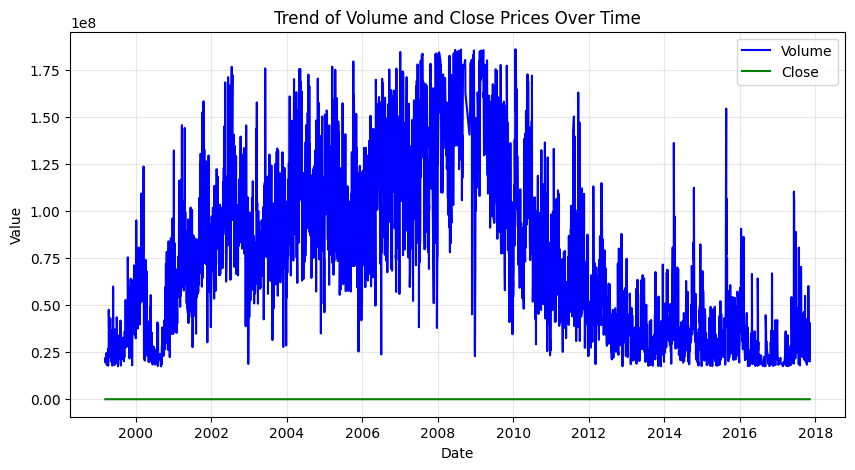

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(categorized_df['Date'], categorized_df['Volume'], label='Volume', color='blue')
plt.plot(categorized_df['Date'], categorized_df['Close'], label='Close', color='green')
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Trend of Volume and Close Prices Over Time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Seasonality Analysis

In [6]:
categorized_df['Year'] = categorized_df['Date'].dt.year
categorized_df['Month'] = categorized_df['Date'].dt.month
categorized_df

,Date,Open,High,Low,Close,Volume,Open_category,High_category,Low_category,Close_category,Volume_category,Year,Month
0,1999-03-11,45.994,46.260,44.988,45.880,21670048,"(44.998, 47.088]","(45.505, 47.593]","(44.8, 46.887]","(45.124, 47.216]","(19838994.529, 22246375.057]",1999,3
1,1999-03-12,45.721,45.749,44.406,44.770,19553768,"(44.998, 47.088]","(45.505, 47.593]","(42.713, 44.8]","(43.033, 45.124]","(17263097.362000003, 19838994.529]",1999,3
2,1999-03-23,44.991,45.160,43.567,43.650,24517597,"(42.908, 44.998]","(43.417, 45.505]","(42.713, 44.8]","(43.033, 45.124]","(22246375.057, 24653755.586]",1999,3
3,1999-03-24,44.045,45.164,43.374,45.136,18890150,"(42.908, 44.998]","(43.417, 45.505]","(42.713, 44.8]","(45.124, 47.216]","(17263097.362000003, 19838994.529]",1999,3
4,1999-03-25,45.829,46.776,45.529,46.776,18192179,"(44.998, 47.088]","(45.505, 47.593]","(44.8, 46.887]","(45.124, 47.216]","(17263097.362000003, 19838994.529]",1999,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4226,2017-11-03,152.390,153.290,151.840,153.270,26199249,"(151.58, 153.67]","(151.994, 154.082]","(151.253, 153.34]","(151.779, 153.87]","(24653755.586, 27061136.114]",2017,11
4227,2017-11-06,153.130,153.850,153.100,153.750,28685854,"(151.58, 153.67]","(151.994, 154.082]","(151.253, 153.34]","(151.779, 153.87]","(27061136.114, 29468516.643]",2017,11
4228,2017-11-07,153.670,154.082,153.340,153.870,21285469,"(151.58, 153.67]","(151.994, 154.082]","(151.253, 153.34]","(151.779, 153.87]","(19838994.529, 22246375.057]",2017,11
4229,2017-11-09,153.260,153.770,152.110,153.690,40554952,"(151.58, 153.67]","(151.994, 154.082]","(151.253, 153.34]","(151.779, 153.87]","(39098038.757, 41505419.286]",2017,11


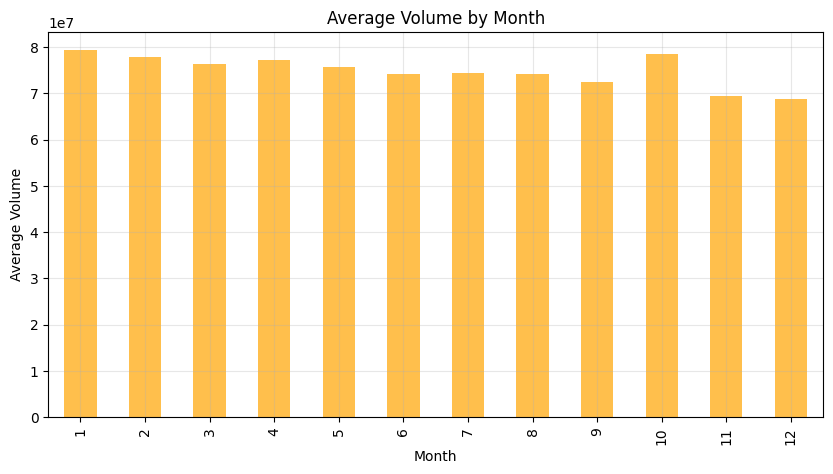

In [7]:
# Calculate the average trading volume for each month
monthly_avg_volume = categorized_df.groupby('Month')['Volume'].mean()

# Plot the monthly volume changes
plt.figure(figsize=(10, 5))
monthly_avg_volume.plot(kind='bar', color='orange', alpha=0.7)
plt.title("Average Volume by Month")
plt.xlabel("Month")
plt.ylabel("Average Volume")
plt.grid(alpha=0.3)
plt.show()

#### Lagged Correlation Analysis

Lagged Correlation:
               Volume  Volume_lag1
Volume       1.000000     0.838972
Volume_lag1  0.838972     1.000000


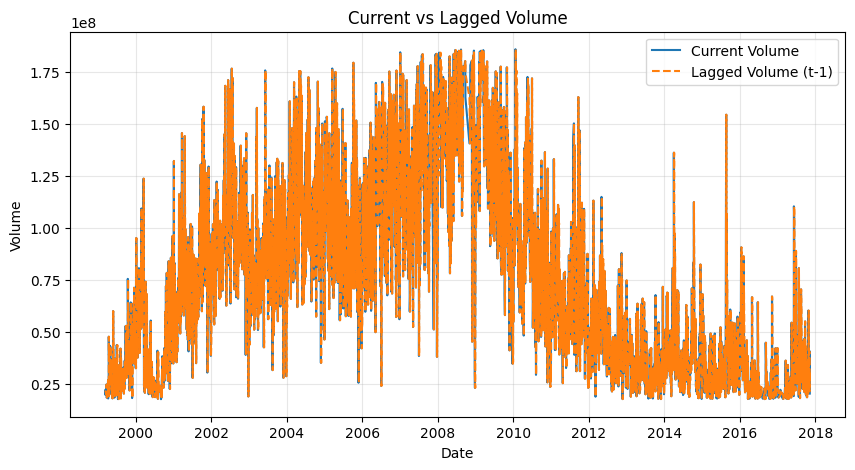

In [8]:
# Create a lagged version of the Volume column (lag)
categorized_df['Volume_lag1'] = categorized_df['Volume'].shift(1)

# Calculate the correlation between the current and lagged Volume
lagged_corr = categorized_df[['Volume', 'Volume_lag1']].corr()
print("Lagged Correlation:")
print(lagged_corr)

# Plot a comparison chart
plt.figure(figsize=(10, 5))
plt.plot(categorized_df['Date'], categorized_df['Volume'], label='Current Volume')
plt.plot(categorized_df['Date'], categorized_df['Volume_lag1'], label='Lagged Volume (t-1)', linestyle='--')
plt.xlabel("Date")
plt.ylabel("Volume")
plt.title("Current vs Lagged Volume")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Cumulative Analysis

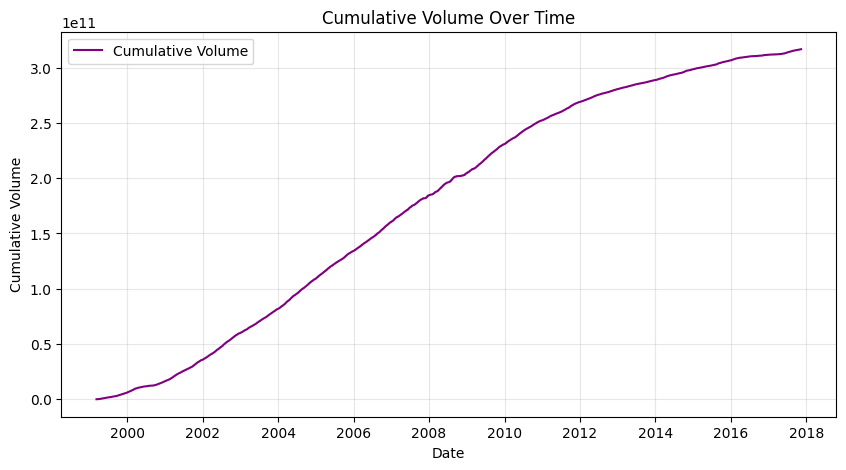

In [9]:
categorized_df['Cumulative_Volume'] = categorized_df['Volume'].cumsum()

plt.figure(figsize=(10, 5))
plt.plot(categorized_df['Date'], categorized_df['Cumulative_Volume'], color='purple', label='Cumulative Volume')
plt.xlabel("Date")
plt.ylabel("Cumulative Volume")
plt.title("Cumulative Volume Over Time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Moving Average Analysis

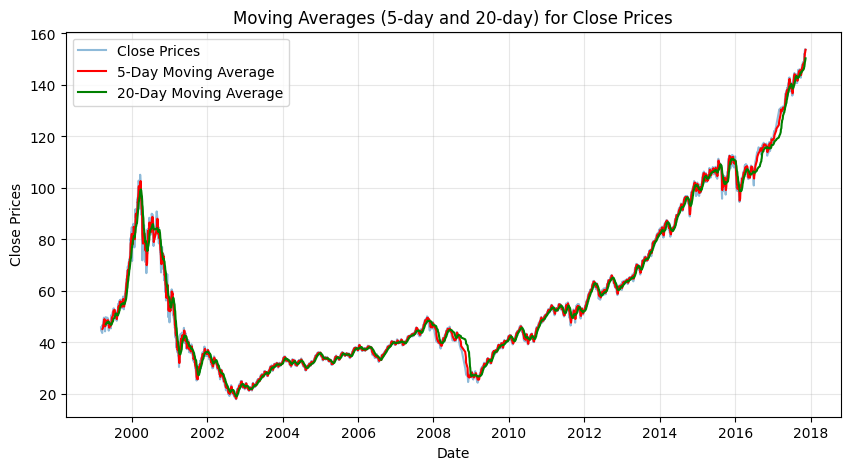

In [10]:
categorized_df['MA_5'] = categorized_df['Close'].rolling(window=5).mean()
categorized_df['MA_20'] = categorized_df['Close'].rolling(window=20).mean()

plt.figure(figsize=(10, 5))
plt.plot(categorized_df['Date'], categorized_df['Close'], label='Close Prices', alpha=0.5)
plt.plot(categorized_df['Date'], categorized_df['MA_5'], label='5-Day Moving Average', color='red')
plt.plot(categorized_df['Date'], categorized_df['MA_20'], label='20-Day Moving Average', color='green')
plt.xlabel("Date")
plt.ylabel("Close Prices")
plt.title("Moving Averages (5-day and 20-day) for Close Prices")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Change point detection

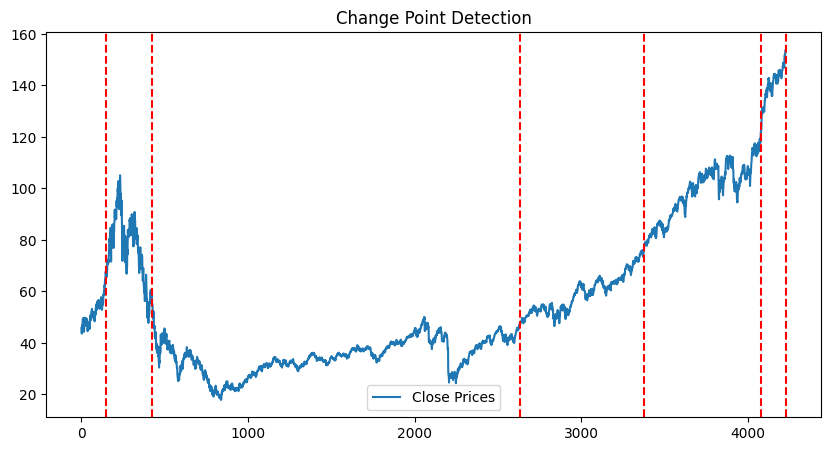

In [11]:
signal = categorized_df['Close'].values
algo = Binseg(model="l2").fit(signal)
change_points = algo.predict(n_bkps=5)

plt.figure(figsize=(10, 5))
plt.plot(signal, label="Close Prices")
for cp in change_points:
    plt.axvline(cp, color='red', linestyle='--')
plt.title("Change Point Detection")
plt.legend()
plt.show()

#### Volatility and Returns Analysis

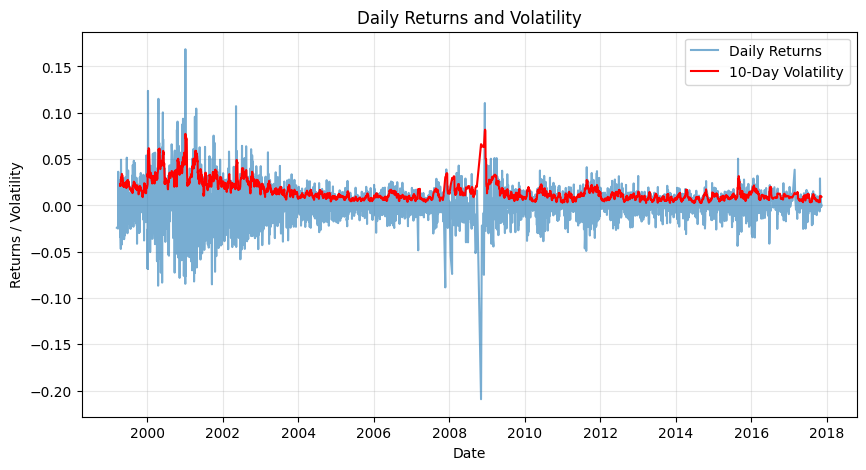

In [12]:
# Calculate daily returns
categorized_df['Daily_Return'] = categorized_df['Close'].pct_change()  # Percentage change for daily returns

# Calculate volatility
volatility = categorized_df['Daily_Return'].rolling(window=10).std()

# Plot daily returns and volatility
plt.figure(figsize=(10, 5))
plt.plot(categorized_df['Date'], categorized_df['Daily_Return'], label='Daily Returns', alpha=0.6)
plt.plot(categorized_df['Date'], volatility, label='10-Day Volatility', color='red')
plt.xlabel("Date")
plt.ylabel("Returns / Volatility")
plt.title("Daily Returns and Volatility")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Autocorrelation Analysis

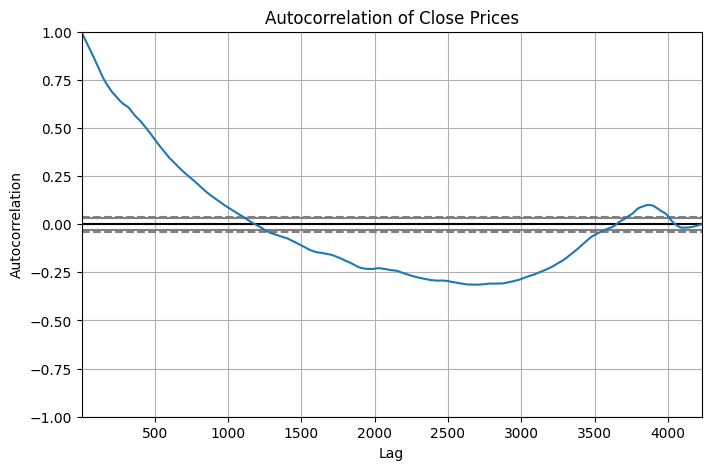

In [13]:
plt.figure(figsize=(8, 5))
autocorrelation_plot(categorized_df['Close'])
plt.title("Autocorrelation of Close Prices")
plt.show()